In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/MATH6912/Project/data.csv')

In [ ]:
train_data, temp_data = train_test_split(data, train_size=4500, random_state=1, shuffle=True)
val_data, test_data = train_test_split(temp_data, train_size=1000, random_state=0, shuffle=True)

In [ ]:
# Calculate the proportion of bankrupt companies in the entire dataset
bankrupt_proportion = data['Bankrupt?'].value_counts(normalize=True)
print(f"Proportion of bankrupt companies in the dataset:\n{bankrupt_proportion}")

# Calculate the proportion of bankrupt companies in the training set
train_bankrupt_proportion = train_data['Bankrupt?'].value_counts(normalize=True)
print(f"\nProportion of bankrupt companies in the training set:\n{train_bankrupt_proportion}")

# Calculate the proportion of bankrupt companies in the validation set
val_bankrupt_proportion = val_data['Bankrupt?'].value_counts(normalize=True)
print(f"\nProportion of bankrupt companies in the validation set:\n{val_bankrupt_proportion}")

# Calculate the proportion of bankrupt companies in the test set
test_bankrupt_proportion = test_data['Bankrupt?'].value_counts(normalize=True)
print(f"\nProportion of bankrupt companies in the test set:\n{test_bankrupt_proportion}")

Proportion of bankrupt companies in the dataset:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

Proportion of bankrupt companies in the training set:
Bankrupt?
0    0.968
1    0.032
Name: proportion, dtype: float64

Proportion of bankrupt companies in the validation set:
Bankrupt?
0    0.968
1    0.032
Name: proportion, dtype: float64

Proportion of bankrupt companies in the test set:
Bankrupt?
0    0.966641
1    0.033359
Name: proportion, dtype: float64


In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Separate features (X) and target variable (y) for the training data
X_train = train_data.drop('Bankrupt?', axis=1)
y_train = train_data['Bankrupt?']

# Initialize RandomOverSampler
oversampler = RandomOverSampler(sampling_strategy=0.5, random_state=0)

# Resample the training data
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Create a new balanced training DataFrame
train_data_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
train_data_resampled['Bankrupt?'] = y_train_resampled

In [ ]:
# Separate features and target variable
X_train = train_data.drop('Bankrupt?', axis=1)
y_train = train_data['Bankrupt?']

# Initialize SMOTE with the desired sampling strategy
smote = SMOTE(sampling_strategy=0.5, random_state=0)

# Apply SMOTE to oversample the minority class
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
# Separate features and target variable
X_test = test_data.drop('Bankrupt?', axis=1)
y_test = test_data['Bankrupt?']

# Initialize SMOTE with the desired sampling strategy
smote = SMOTE(sampling_strategy=0.5, random_state=0)

# Apply SMOTE to oversample the minority class
X_test_resampled, y_test_resampled = smote.fit_resample(X_test, y_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

standardscalar = StandardScaler()

scaled_X = standardscalar.fit_transform(X_train)
scaled_X_test = standardscalar.transform(X_test_resampled)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000)

In [ ]:
print(logreg.coef_)

[[-7.43478813e-13 -8.70561643e-13 -7.88073157e-13 -8.83731605e-14
  -8.80145248e-14 -1.20292347e-14 -1.29770316e-14 -1.27998674e-14
  -7.72567857e-15 -1.23508901e-14 -8.43861929e-12 -9.57273021e-11
  -5.67366740e-14 -4.59740936e-09 -6.45855952e-13 -2.60745013e-13
  -2.62119745e-13 -2.61519720e-13 -3.53018532e-13 -5.76280938e-14
  -1.97155590e-06 -1.84198438e-13 -3.26092801e-13  3.58312808e-15
  -1.67625773e-14 -3.03604177e-14 -3.05929115e-14 -3.83617215e-15
  -1.09678158e-10 -1.41628335e-15 -1.18300689e-14  2.95370096e-15
  -2.19032551e-06  2.47429855e-10 -1.35186258e-14  2.40569943e-10
   6.46102176e-13 -6.56317618e-13 -1.09601781e-14  1.21000233e-13
   6.07980695e-14 -1.81213225e-13 -3.08448913e-13  2.09951563e-14
  -2.43767606e-13 -1.93298014e-06 -2.42414716e-06 -2.29517117e-11
   1.03137575e-10  8.14969609e-14  3.02455078e-06 -1.52574388e-13
  -1.09592765e-06 -5.00977117e-13 -4.75972369e-13 -2.20884936e-13
  -6.65110011e-13 -3.96896793e-07  3.88326319e-10  4.85199533e-13
  -1.11062

In [ ]:
logreg2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', C = 0.01, class_weight = 'balanced')
logreg2.fit(scaled_X, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')

In [ ]:
print(logreg2.coef_)

[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.         -0.0142718   0.          0.
   0.          0.          0.          0.          0.          0.
  -0.61959579  0.          0.          0.          0.          0.02290474
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.10148362
   0.45509185 -0.43139791  0.          0.          0.          0.
   0.          0.         -0.13163832  0.          0.          0.
   0.08713663  0.          0.          0.          0.         -0.09671311
   0.          0.         -0.1907748   0.          0.02614536  0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.         -0.14173242  0.          0.          0.          0.
   0.          0.         -0.03442551  0.          0.          0.01659617
   0.         -0.52042498  0.          0.   

In [ ]:
# prompt: Find the name of the features with non zero coefficients in logreg2

import numpy as np

# Get the coefficients of the logistic regression model
coefficients = logreg2.coef_

# Find the indices where the coefficients are non-zero
non_zero_indices = np.where(coefficients != 0)[1]

# Get the feature names corresponding to the non-zero coefficients
feature_names = X_train.columns[non_zero_indices]

# Print the names of the features with non-zero coefficients
feature_names


Index([' Continuous interest rate (after tax)',
       ' Persistent EPS in the Last Four Seasons',
       ' Realized Sales Gross Profit Growth Rate',
       ' Total debt/Total net worth', ' Debt ratio %', ' Net worth/Assets',
       ' Total Asset Turnover', ' Fixed Assets Turnover Frequency',
       ' Working Capital to Total Assets', ' Cash/Total Assets',
       ' Cash/Current Liability', ' Cash Turnover Rate',
       ' Cash Flow to Liability', ' Current Liability to Current Assets',
       ' Net Income to Total Assets'],
      dtype='object')

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on training set
y_train_pred = logreg.predict(X_train_resampled)

# Evaluate on training set
print("\nTraining Set (Resampled):")
print("Confusion Matrix:\n", confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report:\n", classification_report(y_train_resampled, y_train_pred))


# Prepare data for evaluation
X_val = val_data.drop('Bankrupt?', axis=1)
y_val = val_data['Bankrupt?']
X_test = test_data.drop('Bankrupt?', axis=1)
y_test = test_data['Bankrupt?']

# Predict on validation set
y_val_pred = logreg.predict(X_val)

# Evaluate on validation set
print("Validation Set:")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

# Predict on test set
y_test_pred = logreg.predict(X_test)

# Evaluate on test set
print("\nTest Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Training Set (Resampled):
Confusion Matrix:
 [[4092  264]
 [1821  357]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.94      0.80      4356
           1       0.57      0.16      0.26      2178

    accuracy                           0.68      6534
   macro avg       0.63      0.55      0.53      6534
weighted avg       0.65      0.68      0.62      6534

Validation Set:
Confusion Matrix:
 [[907  61]
 [ 28   4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       968
           1       0.06      0.12      0.08        32

    accuracy                           0.91      1000
   macro avg       0.52      0.53      0.52      1000
weighted avg       0.94      0.91      0.93      1000


Test Set:
Confusion Matrix:
 [[1202   73]
 [  36    8]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on training set
y_train_pred = logreg2.predict(X_train_resampled)

# Evaluate on training set
print("\nTraining Set (Resampled):")
print("Confusion Matrix:\n", confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report:\n", classification_report(y_train_resampled, y_train_pred))


# Prepare data for evaluation
X_val = val_data.drop('Bankrupt?', axis=1)
y_val = val_data['Bankrupt?']
X_test = test_data.drop('Bankrupt?', axis=1)
y_test = test_data['Bankrupt?']

# Predict on validation set
y_val_pred = logreg2.predict(X_val)

# Evaluate on validation set
print("Validation Set:")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

# Predict on test set
y_test_pred = logreg2.predict(X_test)

# Evaluate on test set
print("\nTest Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Training Set (Resampled):
Confusion Matrix:
 [[3790  566]
 [1550  628]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.87      0.78      4356
           1       0.53      0.29      0.37      2178

    accuracy                           0.68      6534
   macro avg       0.62      0.58      0.58      6534
weighted avg       0.65      0.68      0.65      6534

Validation Set:
Confusion Matrix:
 [[831 137]
 [ 25   7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91       968
           1       0.05      0.22      0.08        32

    accuracy                           0.84      1000
   macro avg       0.51      0.54      0.50      1000
weighted avg       0.94      0.84      0.88      1000


Test Set:
Confusion Matrix:
 [[1105  170]
 [  30   14]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


[0.35357121 0.26905226 0.19153723 ... 0.50328312 0.21360097 0.39924797]
AUC random predictions = 0.5
AUC predictions from logistic regression model = 0.7138510788930957
AUC predictions from penalized logistic regression model = 0.950445408932804


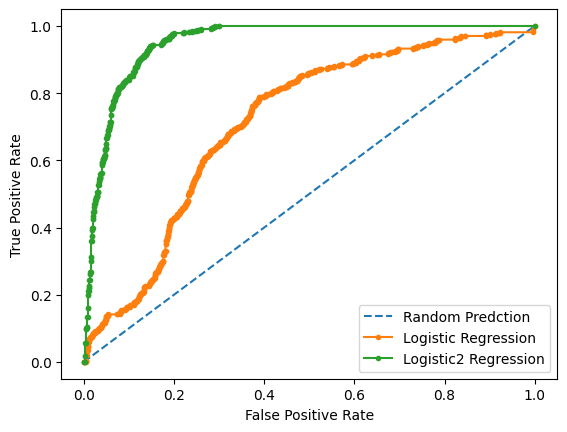

In [ ]:

# Calculate the receiver operating curve and the AUC measure

lr_prob=logreg.predict_proba(X_test_resampled)
lr_prob2=logreg2.predict_proba(scaled_X_test)
lr_prob=lr_prob[:, 1]
lr_prob2 = lr_prob2[:, 1]
print(lr_prob)
ns_prob=[0 for _ in range(len(y_test_resampled))]
ns_auc=roc_auc_score(y_test_resampled, ns_prob)
lr_auc=roc_auc_score(y_test_resampled,lr_prob)
ns_prob2=[0 for _ in range(len(y_test_resampled))]
ns_auc2=roc_auc_score(y_test_resampled, ns_prob2)
lr_auc2=roc_auc_score(y_test_resampled,lr_prob2)
print("AUC random predictions =", ns_auc)
print("AUC predictions from logistic regression model =", lr_auc)
print("AUC predictions from penalized logistic regression model =", lr_auc2)
ns_fpr,ns_tpr,_=roc_curve(y_test_resampled,ns_prob)
lr_fpr,lr_tpr,_=roc_curve(y_test_resampled,lr_prob)
ns_fpr2,ns_tpr2,_=roc_curve(y_test_resampled,ns_prob2)
lr_fpr2,lr_tpr2,_=roc_curve(y_test_resampled,lr_prob2)

plt.plot(ns_fpr,ns_tpr,linestyle='--',label='Random Predction')
plt.plot(lr_fpr,lr_tpr,marker='.',label='Logistic Regression')
plt.plot(lr_fpr2,lr_tpr2,marker='.',label='Logistic2 Regression')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()